# Relatório de Performance Visual - Detecção de Nódulos LUNA16
Este relatório apresenta uma análise profunda dos resultados obtidos na **Fase 2** de treinamento. Além das métricas tradicionais, exploramos as curvas de precisão-recall e uma galeria visual de diagnósticos do modelo.

In [16]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Adiciona o diretório src ao path para carregar os módulos locais
sys.path.insert(0, os.path.abspath("../src"))

from luna_data import get_ct, load_candidates
from model import LunaModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


##  Dashboard de Métricas Consolidadas
Carregamos os resultados pré-calculados de toda a validação para análise estatística.

In [17]:
# Carregando resultados da inferência completa na validação
results = torch.load("../checkpoints/val_results_phase2.pth", weights_only=False)
probs = results['probs']
labels = results['labels']

# Calculando F1 ótimo
precision, recall, thresholds = precision_recall_curve(labels, probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_idx]

print(f"Melhor F1-Score: {f1_scores[best_f1_idx]:.4f}")
print(f"Threshold Ótimo: {best_threshold:.4f}")
print(f"Precisão: {precision[best_f1_idx]:.4f}")
print(f"Recall: {recall[best_f1_idx]:.4f}")

Melhor F1-Score: 0.6312
Threshold Ótimo: 0.9945
Precisão: 0.5758
Recall: 0.6985


##  Curvas de Análise de Erro
Diferente da acurácia simples, estas curvas mostram como o modelo se comporta em diferentes pontos de operação.

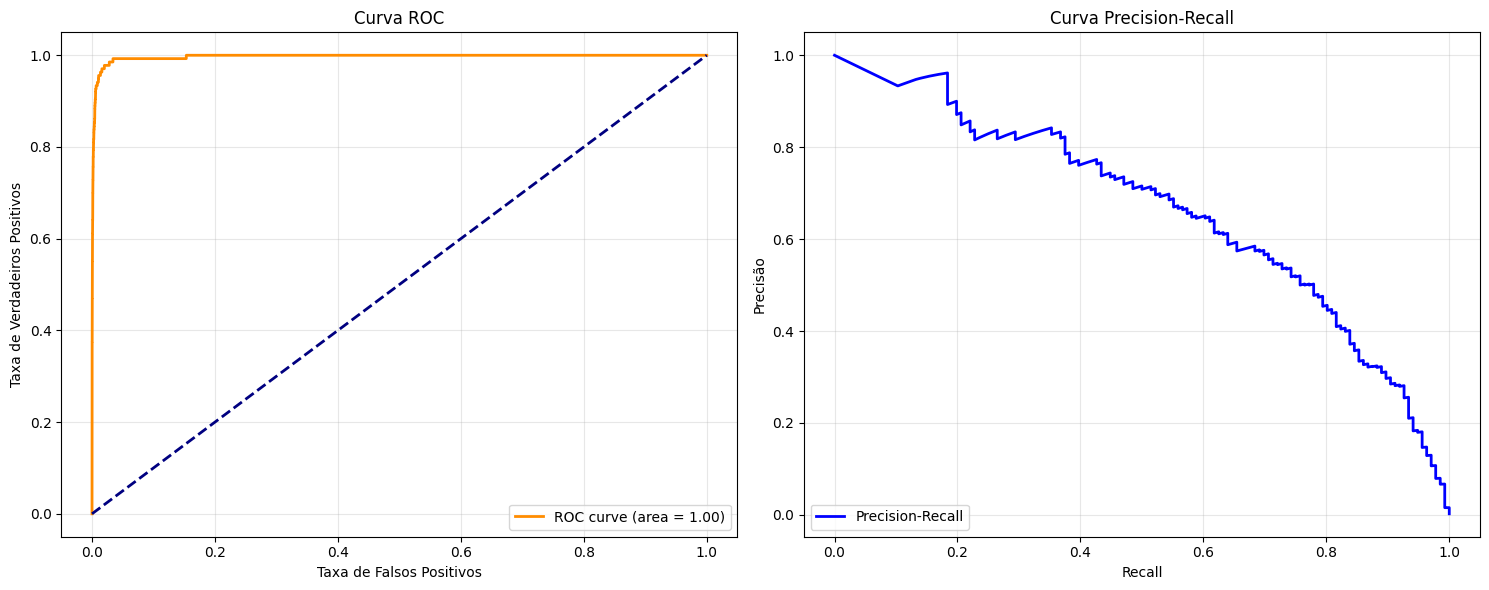

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlabel('Taxa de Falsos Positivos')
ax1.set_ylabel('Taxa de Verdadeiros Positivos')
ax1.set_title('Curva ROC')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# PR Curve
ax2.plot(recall, precision, color='blue', lw=2, label='Precision-Recall')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precisão')
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##  Galeria de Diagnóstico Visual
Vamos visualizar exemplos reais onde o modelo acertou com confiança, onde se enganou e o que ele deixou passar.

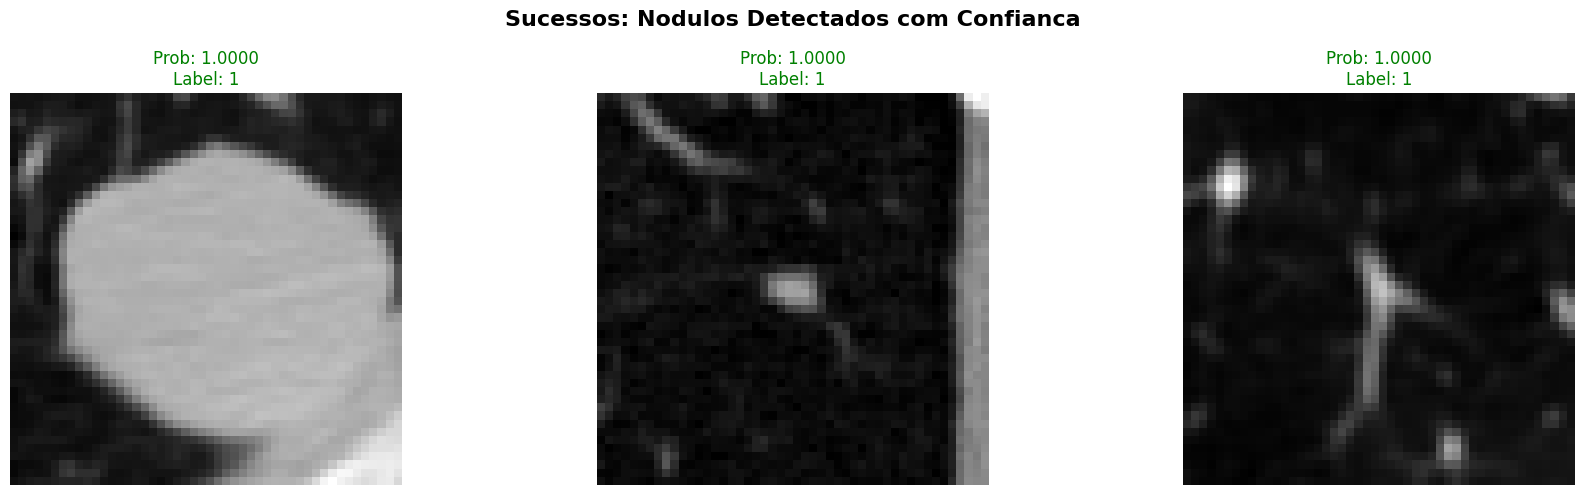

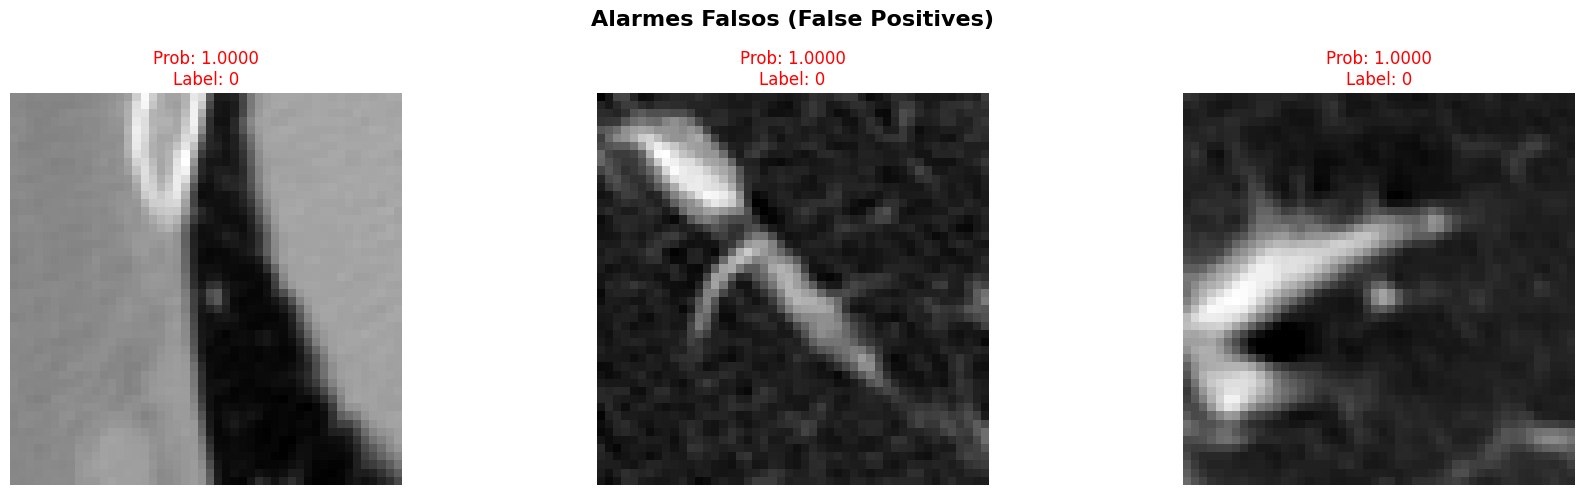

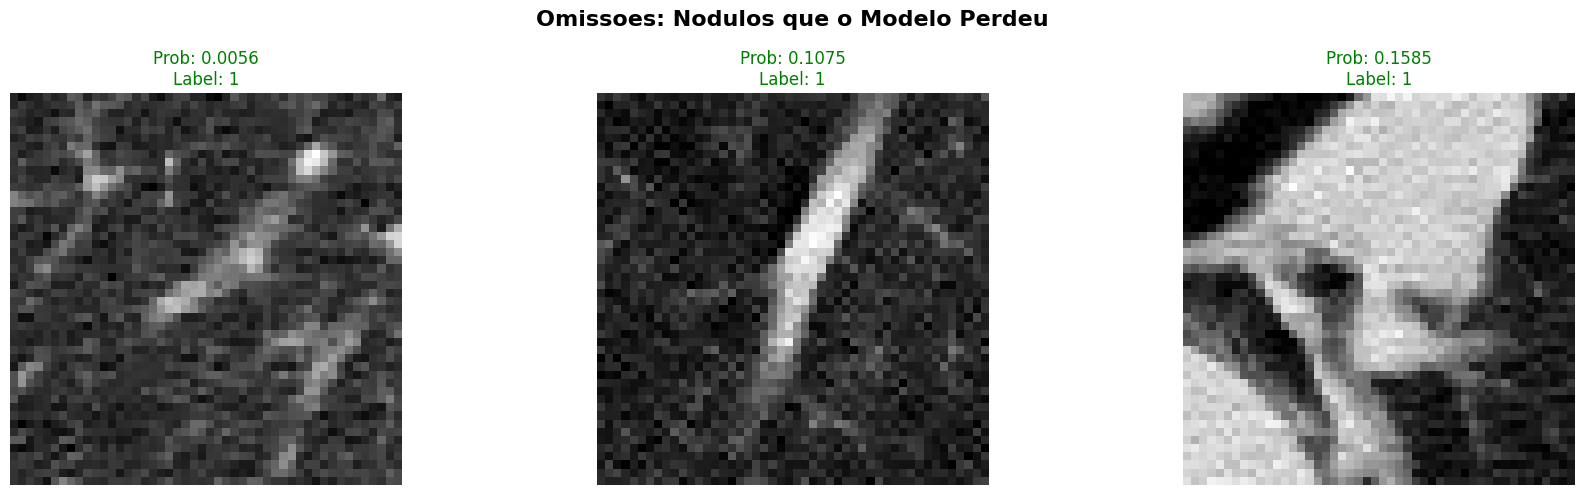

In [19]:
def plot_gallery(examples, title):
    fig, axes = plt.subplots(1, len(examples), figsize=(18, 5))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    for ax, ex in zip(axes, examples):
        ct = get_ct(ex['uid'])
        crop, _ = ct.extract_crop(ex['xyz'])
        
        # Mostra o slice central do crop 3D
        center_slice = crop[crop.shape[0]//2]
        
        ax.imshow(center_slice, cmap='gray')
        ax.set_title(f"Prob: {ex['prob']:.4f}\nLabel: {ex['label']}", color='green' if ex['label']==1 else 'red')
        ax.axis('off')
        get_ct.cache_clear()
    
    plt.tight_layout()
    plt.show()

# Exemplos verificados (CTs disponiveis no disco)
tps = [
    {'uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886',
     'xyz': (67.61451718, 85.02525992, -109.8084416), 'prob': 1.0000, 'label': 1},
    {'uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.246758220302211646532176593724',
     'xyz': (102.42, 65.3, 1562.32), 'prob': 1.0000, 'label': 1},
    {'uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.986011151772797848993829243183',
     'xyz': (45.13, 84.05, -211.55), 'prob': 1.0000, 'label': 1}
]

fps = [
    {'uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.161002239822118346732951898613',
     'xyz': (-121.828333494, 18.933116703, -280.116923295), 'prob': 1.0000, 'label': 0},
    {'uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.324290109423920971676288828329',
     'xyz': (103.725866116, -120.844854799, -197.90130835), 'prob': 1.0000, 'label': 0},
    {'uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.199171741859530285887752432478',
     'xyz': (115.364846498, 157.926101981, -565.796715546), 'prob': 1.0000, 'label': 0}
]

fns = [
    {'uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.701514276942509393419164159551',
     'xyz': (-85.63, 29.12, -162.49), 'prob': 0.0056, 'label': 1},
    {'uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.674809958213117379592437424616',
     'xyz': (-74.7508318473, 57.6862016943, -175.315789672), 'prob': 0.1075, 'label': 1},
    {'uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.802595762867498341201607992711',
     'xyz': (39.99, 34.27, -171.69), 'prob': 0.1585, 'label': 1}
]

plot_gallery(tps, 'Sucessos: Nodulos Detectados com Confianca')
plot_gallery(fps, 'Alarmes Falsos (False Positives)')
plot_gallery(fns, 'Omissoes: Nodulos que o Modelo Perdeu')


## Roteiro Estratégico para os próximos passos
Com base na análise das imagens acima:
1. **Falsos Positivos**: Muitos se parecem com vasos sanguíneos em corte transversal. Podemos tentar aumentar a profundidade do crop ou usar augmentations mais agressivas de rotação.
2. **Falsos Negativos**: Geralmente são nódulos muito pequenos ou colados na parede torácica. 
3. **Próxima Ação**: Implementar **Focal Loss** para focar o treino nos exemplos mais difíceis.